In [1]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

from src.utils import time_embedding_np, reward_simulate, simulate_data_raw, make_weighted_target, position_encoder
from src.utils import best_next_state, path_opt, preward_opt, compute_normalized_future_rewards
from src.rl import TabularQLearner, FQILearner

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

In [3]:
total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [4]:
actions, states, irewards, times = simulate_data_raw(
    rewards_in_period=rewards_in_period,
    session_duration=500000,
    tdim=50, 
    n_sessions=1,
    seed=515
)
states = states[:, 0].astype(int)

In [5]:
experiences = []
for s, a, r, t in zip(states, actions, irewards, times):
    experiences.append((s, a, r, t))

In [6]:
def next_state(current_state, action):
    next_state = current_state + action
    if current_state == 0 and next_state < 0:
        next_state = 0
    if current_state == 6 and next_state > 6:
        next_state = 6
    return next_state

In [7]:
def fit_and_evaluate(t, learner, experiences, fit_iterations=100, gamma=0.5, eval_period=100):
    # fit the learner
    learner.reset()
    learner.fit(experiences[:t], num_iterations=fit_iterations)
    
    # get the future states using the learned policy
    current_state, _, _, _ = experiences[t]
    pred_states = [current_state]
    for step in range(t, t+eval_period):
        action = learner.greedy_policy(current_state, step)
        current_state = next_state(current_state, action)
        pred_states.append(current_state)

    # evaluate
    irewards_test = [reward_simulate(pred_states[i], t+i, rewards_in_period) for i in np.arange(1, len(pred_states))]
    preward = compute_normalized_future_rewards(irewards_test, eval_period, gamma)
    optimal_states, ireward_opt = path_opt(pred_states[0], t, eval_period)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], eval_period, gamma)
    pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / eval_period

    return {
        "pregret": pregret,
        "pred_states": pred_states,
        "optimal_states": optimal_states
    }

In [8]:
t_list = [128, 512, 1024, 2048, 4096, 10000, 20000, 50000]

# Tabular Q-learning without time
learner = TabularQLearner(num_states=7, num_actions=3, gamma=0.9, include_time=False)
results_tabq = []
for t in t_list:
    result = fit_and_evaluate(t, learner, experiences)
    results_tabq.append(result)

# Tabular Q-learning with time (period unknown)
learner = TabularQLearner(num_states=7, num_actions=3, gamma=0.9, include_time=True, tsize=10)
results_tabq_time_unknown_period = []
for t in t_list:
    result = fit_and_evaluate(t, learner, experiences)
    results_tabq_time_unknown_period.append(result)

# Tabular Q-learning with time (period known)
learner = TabularQLearner(num_states=7, num_actions=3, gamma=0.9, include_time=True, tsize=20)
results_tabq_time_exact_period = []
for t in t_list:
    result = fit_and_evaluate(t, learner, experiences)
    results_tabq_time_exact_period.append(result)

# Tabular Q-learning with time (harmonic of the period)
learner = TabularQLearner(num_states=7, num_actions=3, gamma=0.9, include_time=True, tsize=40)
results_tabq_time_harmonic_period = []
for t in t_list:
    result = fit_and_evaluate(t, learner, experiences)
    results_tabq_time_harmonic_period.append(result)

In [16]:
# Save
results_list = [
    results_tabq,
    results_tabq_time_unknown_period,
    results_tabq_time_exact_period,
    results_tabq_time_harmonic_period
]

names_list = [
    'tabql_notime',
    'tabql_unknown_period',
    'tabql_known_period',
    'tabql_harmonic_period',
]

for results, name in zip(results_list, names_list):
    pregret_list = [res["pregret"] for res in results]
    file = f"../results/RL/pregret_{name}.npz"
    np.savez(file, t_list=t_list, pregret_list=pregret_list)

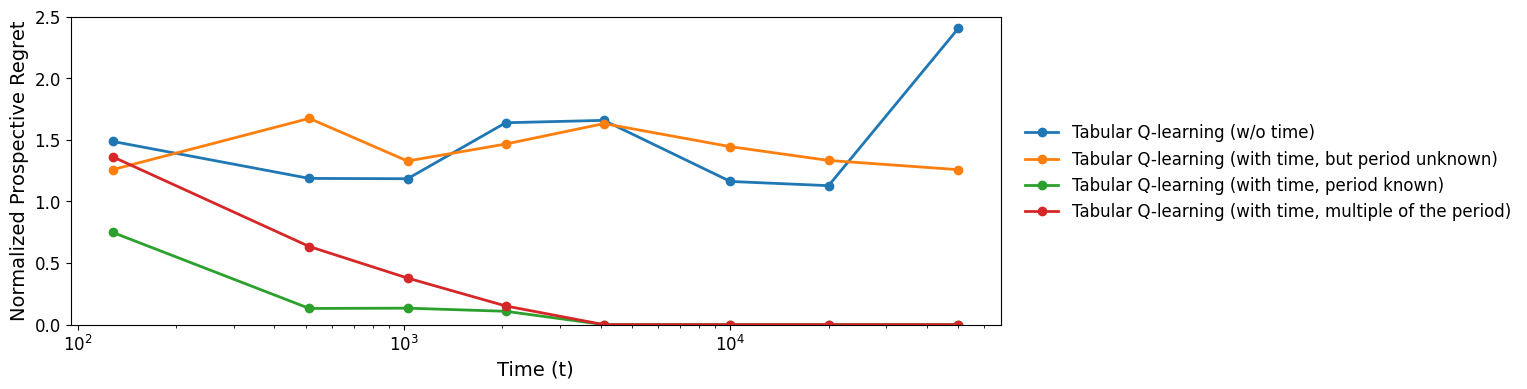

In [9]:
fontsize = 14
lw=2
fig, ax = plt.subplots(figsize=(12, 4))

pregret_list = [res["pregret"] for res in results_tabq]
ax.plot(t_list, pregret_list, marker='o', label='Tabular Q-learning (w/o time)', lw=lw)

pregret_list = [res["pregret"] for res in results_tabq_time_unknown_period]
ax.plot(t_list, pregret_list, marker='o', label='Tabular Q-learning (with time, but period unknown)', lw=lw)

pregret_list = [res["pregret"] for res in results_tabq_time_exact_period]
ax.plot(t_list, pregret_list, marker='o', label='Tabular Q-learning (with time, period known)', lw=lw)

pregret_list = [res["pregret"] for res in results_tabq_time_harmonic_period]
ax.plot(t_list, pregret_list, marker='o', label='Tabular Q-learning (with time, multiple of the period)', lw=lw)

ax.set_xlabel("Time (t)", fontsize=fontsize)
ax.set_ylabel("Normalized Prospective Regret", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize-2)
ax.legend(fontsize=fontsize-2, bbox_to_anchor=(1.01, 0.7), loc='upper left', frameon=False)
ax.set_ylim([0, 2.5])
ax.set_xscale('log')
plt.show()

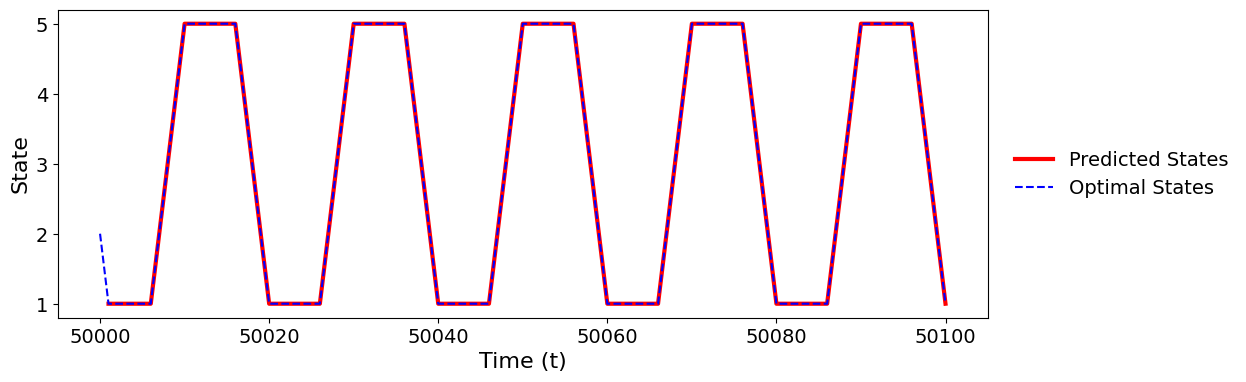

In [10]:
fontsize = 16
fig, ax = plt.subplots(figsize=(12, 4))

pred_states = [res["pred_states"] for res in results_tabq_time_exact_period][-1]
optimal_states = [res["optimal_states"] for res in results_tabq_time_exact_period][-1]
t = t_list[-1]

ax.plot(np.arange(t+1, t+101), pred_states[1:], lw=3, color='red', label='Predicted States')
ax.plot(np.arange(t,t+101), optimal_states, lw=1.5, color='blue', linestyle='--', label='Optimal States')
ax.set_xlabel("Time (t)", fontsize=fontsize)
ax.set_ylabel("State", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize-2)
ax.legend(fontsize=fontsize-2, bbox_to_anchor=(1.01, 0.6), loc='upper left', frameon=False)
plt.show()

In [ ]:
t_list = [128, 512, 1024, 2048, 4096, 10000, 20000, 50000]

# Tabular Q-learning without time
learner = FQILearner(include_time=False)
results_without_time = []
for t in t_list:
    result = fit_and_evaluate(t, learner, experiences, fit_iterations=20)
    results_without_time.append(result)

# Tabular Q-learning with time
learner = FQILearner(include_time=True)
results_with_time = []
for t in t_list:
    result = fit_and_evaluate(t, learner, experiences, fit_iterations=20)
    results_with_time.append(result)

In [17]:
# Save
results_list = [
    results_without_time,
    results_with_time
]

names_list = [
    'fqi_notime',
    'fqi_time',
]

for results, name in zip(results_list, names_list):
    pregret_list = [res["pregret"] for res in results]
    file = f"../results/RL/pregret_{name}.npz"
    np.savez(file, t_list=t_list, pregret_list=pregret_list)

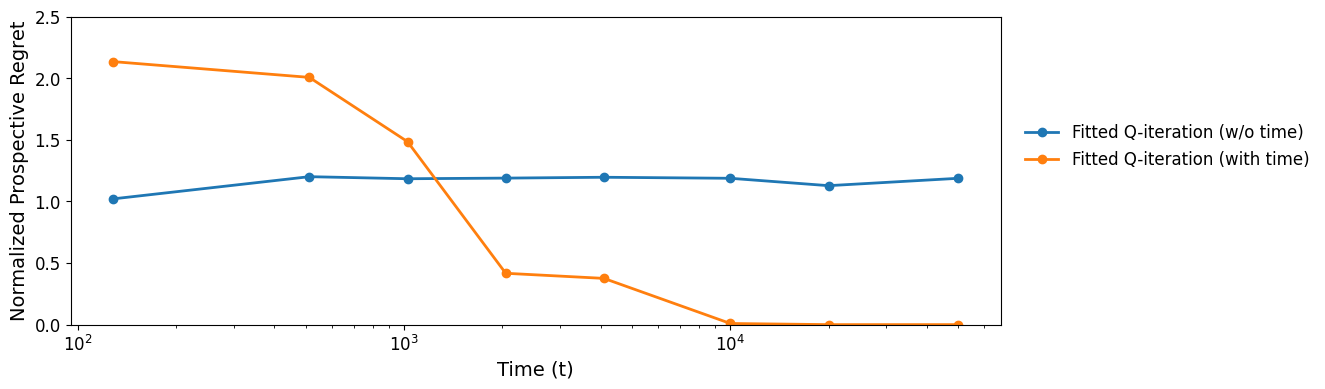

In [18]:
fontsize = 14
lw=2
fig, ax = plt.subplots(figsize=(12, 4))
 
pregret_list = [res["pregret"] for res in results_without_time]
ax.plot(t_list, pregret_list, marker='o', label='Fitted Q-iteration (w/o time)', lw=lw)

pregret_list = [res["pregret"] for res in results_with_time]
ax.plot(t_list, pregret_list, marker='o', label='Fitted Q-iteration (with time)', lw=lw)

ax.set_xlabel("Time (t)", fontsize=fontsize)
ax.set_ylabel("Normalized Prospective Regret", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize-2)
ax.legend(fontsize=fontsize-2, bbox_to_anchor=(1.01, 0.7), loc='upper left', frameon=False)
ax.set_ylim([0, 2.5])
ax.set_xscale('log')
plt.show()

In [13]:
pred_states = [res["pred_states"] for res in results_with_time][-1]
optimal_states = [res["optimal_states"] for res in results_with_time][-1]
t = t_list[-1]

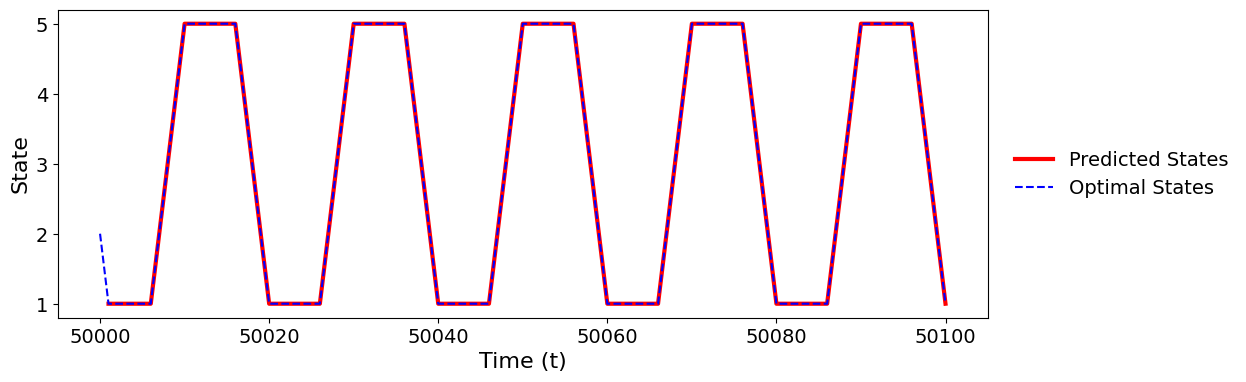

In [14]:
fontsize = 16
fig, ax = plt.subplots(figsize=(12, 4))

pred_states = [res["pred_states"] for res in results_with_time][-1]
optimal_states = [res["optimal_states"] for res in results_with_time][-1]
t = t_list[-1]

ax.plot(np.arange(t+1, t+101), pred_states[1:], lw=3, color='red', label='Predicted States')
ax.plot(np.arange(t,t+101), optimal_states, lw=1.5, color='blue', linestyle='--', label='Optimal States')
ax.set_xlabel("Time (t)", fontsize=fontsize)
ax.set_ylabel("State", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize-2)
ax.legend(fontsize=fontsize-2, bbox_to_anchor=(1.01, 0.6), loc='upper left', frameon=False)
plt.show()